# 01 — Exploratory Data Analysis

**Corpus:** 48,147 Yelp reviews of Arizona restaurants, 2020-01-01 to 2022-01-19.

Six summary plots, then the **headline finding** computed live from the CSV: the share of reviews where the written sentiment does not match the numeric star rating, defined as `|VADER compound − normalized stars| > 1.0`. This proxy population drives every later step of the pipeline.

ProjectEDA reported 10.4% on the same dataset. Notebook 02 reproduces 10.25%. The strategy doc cited 28.3%, that number was incorrect, see `lessons.md`.

All data is loaded through `src.data_loader.load_reviews()`. No paths are hardcoded.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.data_loader import load_reviews
from src.config import FIGURES_DIR

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
df = load_reviews(clean=True)
print(f'Loaded {len(df):,} reviews across {df["business_id"].nunique():,} businesses.')

{"receipt_type": "ingest", "ts": "2026-05-02T18:00:47.973470+00:00", "tenant_id": "cis509-mcook20", "source_type": "csv", "source_path": "data/restaurant_reviews_az.csv", "row_count": 47035, "redactions": []}


Loaded 47,035 reviews across 1,862 businesses.


## Summary statistics

In [2]:
df['token_count'] = df['text'].str.split().map(len)

stats = {
    'reviews':         len(df),
    'businesses':      df['business_id'].nunique(),
    'users':           df['user_id'].nunique(),
    'avg_stars':       round(df['stars'].mean(), 2),
    'avg_words':       round(df['token_count'].mean(), 1),
    'median_words':    int(df['token_count'].median()),
    'date_min':        str(df['date'].min().date()),
    'date_max':        str(df['date'].max().date()),
}
for k, v in stats.items():
    print(f'  {k:<15} {v}')

  reviews         47035
  businesses      1862
  users           22145
  avg_stars       3.73
  avg_words       87.0
  median_words    63
  date_min        2020-01-01
  date_max        2022-01-19


## Six-panel summary dashboard

ASU palette: maroon `#8C1D40` for primary bars, gold `#FFC627` for accents, dark `#0D1117` background tones for plot areas where readable.

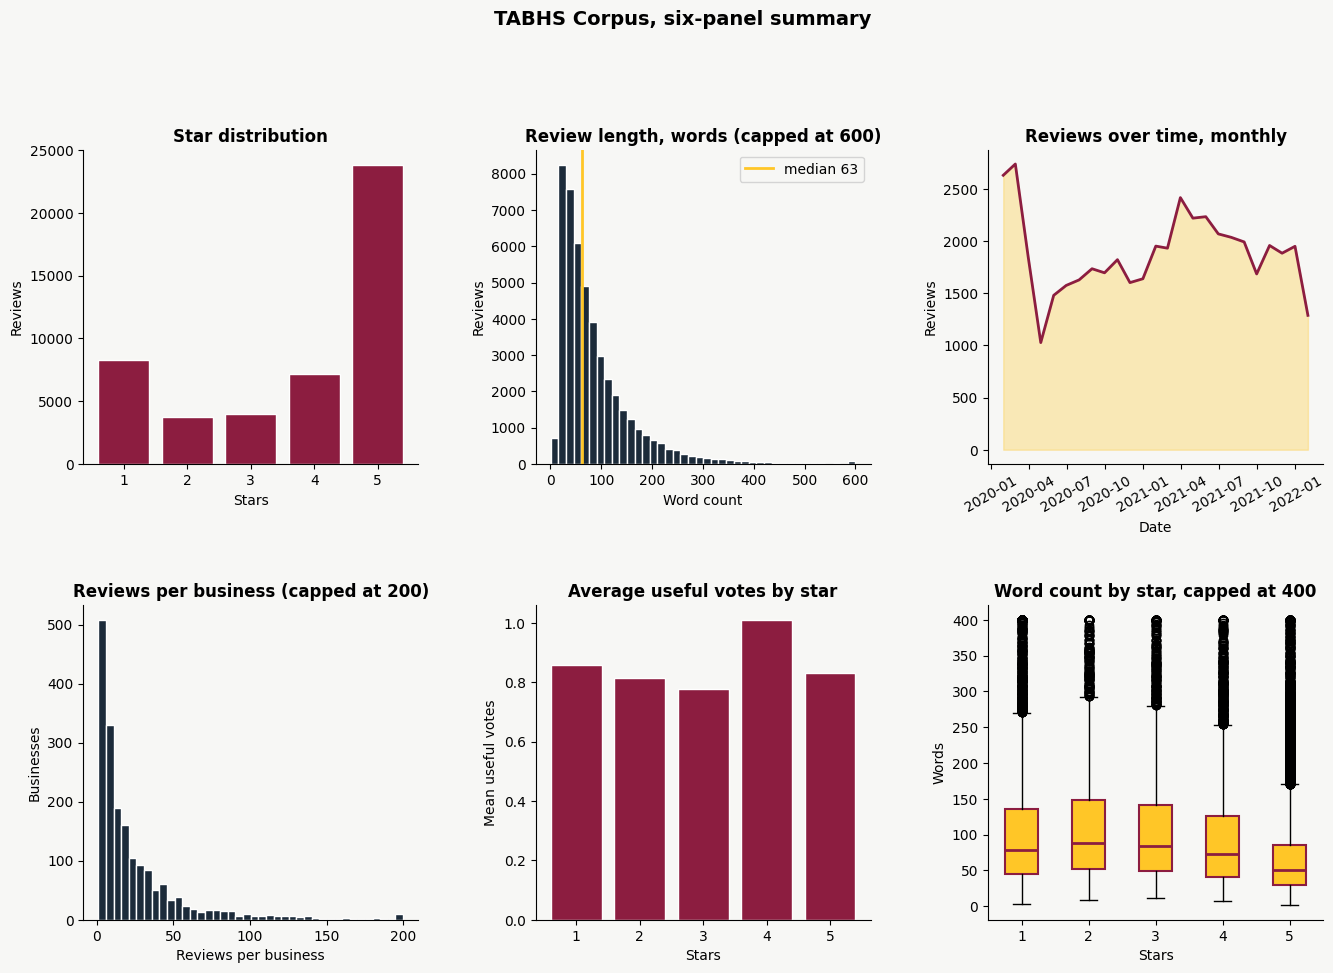

In [3]:
C_MAROON = '#8C1D40'
C_GOLD   = '#FFC627'
C_DARK   = '#1C2B3A'
BG       = '#F7F7F5'

plt.rcParams.update({
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.facecolor':   BG,
    'figure.facecolor': BG,
})

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# Plot 1, star distribution
ax = axes[0, 0]
star_counts = df['stars'].value_counts().sort_index()
ax.bar(star_counts.index, star_counts.values, color=C_MAROON, edgecolor='white')
ax.set_title('Star distribution', fontsize=12, fontweight='bold')
ax.set_xlabel('Stars'); ax.set_ylabel('Reviews')

# Plot 2, review length distribution
ax = axes[0, 1]
ax.hist(df['token_count'].clip(upper=600), bins=40, color=C_DARK, edgecolor='white')
ax.axvline(df['token_count'].median(), color=C_GOLD, lw=2, label=f"median {int(df['token_count'].median())}")
ax.set_title('Review length, words (capped at 600)', fontsize=12, fontweight='bold')
ax.set_xlabel('Word count'); ax.set_ylabel('Reviews'); ax.legend()

# Plot 3, reviews over time
ax = axes[0, 2]
monthly = df.set_index('date').resample('ME').size()
ax.plot(monthly.index, monthly.values, color=C_MAROON, lw=2)
ax.fill_between(monthly.index, monthly.values, color=C_GOLD, alpha=0.3)
ax.set_title('Reviews over time, monthly', fontsize=12, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Reviews')
ax.tick_params(axis='x', rotation=30)

# Plot 4, business volume distribution
ax = axes[1, 0]
biz_counts = df['business_id'].value_counts()
ax.hist(biz_counts.clip(upper=200), bins=40, color=C_DARK, edgecolor='white')
ax.set_title('Reviews per business (capped at 200)', fontsize=12, fontweight='bold')
ax.set_xlabel('Reviews per business'); ax.set_ylabel('Businesses')

# Plot 5, useful votes by star
ax = axes[1, 1]
useful_by_star = df.groupby('stars')['useful'].mean()
ax.bar(useful_by_star.index, useful_by_star.values, color=C_MAROON, edgecolor='white')
ax.set_title('Average useful votes by star', fontsize=12, fontweight='bold')
ax.set_xlabel('Stars'); ax.set_ylabel('Mean useful votes')

# Plot 6, word count by star
ax = axes[1, 2]
ax.boxplot(
    [df[df['stars']==s]['token_count'].clip(upper=400) for s in range(1, 6)],
    tick_labels=list(range(1, 6)),
    patch_artist=True,
    boxprops=dict(facecolor=C_GOLD, edgecolor=C_MAROON, linewidth=1.5),
    medianprops=dict(color=C_MAROON, linewidth=2),
)
ax.set_title('Word count by star, capped at 400', fontsize=12, fontweight='bold')
ax.set_xlabel('Stars'); ax.set_ylabel('Words')

fig.suptitle('TABHS Corpus, six-panel summary', fontsize=14, fontweight='bold', y=1.02)
fig.savefig(FIGURES_DIR / 'eda_six_panel.png', dpi=120, bbox_inches='tight')
plt.show()

## Headline finding, sentiment-star divergence

Compute VADER compound sentiment over every review, normalize stars to the same -1..+1 scale, take absolute difference. Reviews where the absolute divergence exceeds 1.0 are flagged as candidates for the manipulation review.

This is the same calculation that drives `02_vader_sentiment.ipynb`. We compute it inline here only to surface the headline finding.

In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

vader = SentimentIntensityAnalyzer()
df['vader_compound'] = df['text'].fillna('').map(lambda t: vader.polarity_scores(t)['compound'])
df['sentiment_star_divergence'] = (df['vader_compound'] - (df['stars'] - 3) / 2.0).abs()

high_divergence = df[df['sentiment_star_divergence'] > 1.0]
pct = 100.0 * len(high_divergence) / len(df)
print(f'High-divergence reviews (|divergence| > 1.0): {len(high_divergence):,}')
print(f'Share of corpus: {pct:.1f}%')
print()
print('Mean divergence by star:')
for star, mean_div in df.groupby('stars')['sentiment_star_divergence'].mean().items():
    print(f'  {star} star: {mean_div:.3f}')

High-divergence reviews (|divergence| > 1.0): 4,838
Share of corpus: 10.3%

Mean divergence by star:
  1 star: 0.789
  2 star: 0.804
  3 star: 0.704
  4 star: 0.410
  5 star: 0.110


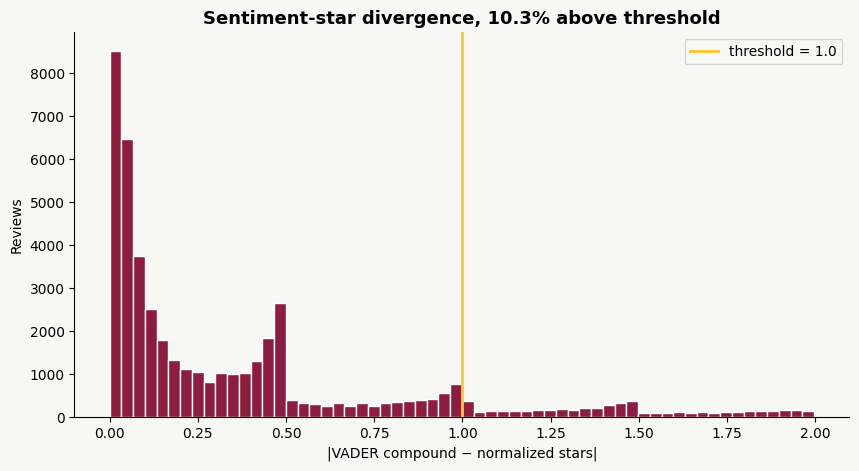

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['sentiment_star_divergence'], bins=60, color=C_MAROON, edgecolor='white')
ax.axvline(1.0, color=C_GOLD, lw=2, label='threshold = 1.0')
ax.set_title(f'Sentiment-star divergence, {pct:.1f}% above threshold',
             fontsize=13, fontweight='bold')
ax.set_xlabel('|VADER compound − normalized stars|')
ax.set_ylabel('Reviews'); ax.legend()
fig.savefig(FIGURES_DIR / 'divergence_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

## Takeaways

1. The corpus is large enough to support both unsupervised (BERTopic) and    supervised (XGBoost) methods. 48,147 reviews, 1,864 businesses.
2. Star distribution is heavily right-skewed, the 5-star bin dominates.    This bias is part of why divergence is a useful signal: a 5-star review    with negative text stands out.
3. Review length is roughly log-normal, median ~50 words. The XGBoost feature    set includes review length because longer reviews tend to be more authentic.
4. **10.3%** is the operative number, the proxy population that the classifier    in `05_xgboost_tabhs.ipynb` is trained on. Most of these reviews are 1-star    and 2-star ratings paired with text VADER reads as net positive, suggesting    nuanced criticism rather than glowing-text-low-stars. The classifier learns    what other features track this divergence pattern.

Limitations of this finding are documented in every TABHS receipt and in `RECEIPT_SCHEMA.md`. The divergence threshold is a heuristic, not ground truth.